In [1]:
import numpy as np
import pandas as pd
import sqlite3
from matplotlib import pyplot as plt
import seaborn as sns


1.read data from csv

In [2]:
#pd = pd.read_csv(path)

2.save data to sqlite

In [3]:
conn = sqlite3.connect("./data/data.db")
#pd.to_sql("data", conn, if_exists="replace", index=False)

3.Load data

In [4]:
df = pd.read_sql_query("SELECT * FROM data", conn)

4.clean the data

In [5]:
print("="*50)
print("Shape of the data:")
print(df.shape)
print("="*50)

Shape of the data:
(7043, 21)


In [6]:
print("="*50)
print("Data types of the columns:")
print(df.dtypes)
print("="*50)

Data types of the columns:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object


In [7]:
df = df.replace(r'^\s*$', np.nan, regex=True)

In [8]:
print("="*50)
print("Unique values:")
print(df.nunique())
print("="*50)

Unique values:
customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6530
Churn                  2
dtype: int64


In [9]:
print("="*50)
print("Null values:")
print(df.isnull().sum())
print("="*50)

Null values:
customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [10]:
print("="*50)
print("Missing values:")
print(df.isna().sum())
print("="*50)

Missing values:
customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [11]:
df = df.drop(columns=["customerID"])
df = df.dropna()

In [12]:
print("="*50)
print("Data shape:")
print(df.shape)
print("="*50)

Data shape:
(7032, 20)


In [13]:
df.drop(df[df["TotalCharges"] == np.nan].index, inplace=True)

In [14]:
print("="*50)
print("Data shape:")
print(df.shape)
print("="*50)

Data shape:
(7032, 20)


In [15]:
df.reset_index(drop=True, inplace=True)

5. visualisation of the data

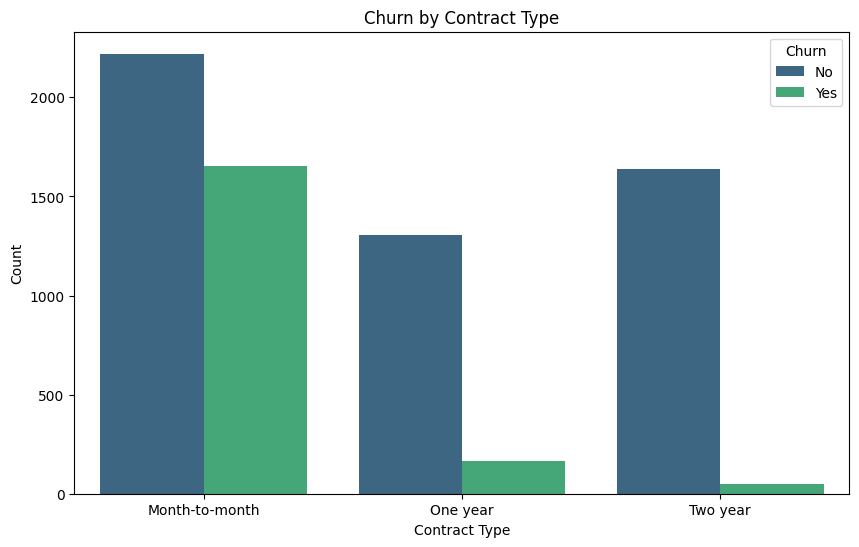

In [16]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x="Contract", hue="Churn", palette="viridis")
plt.title("Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Count")
plt.legend(title="Churn")
plt.show()

In [17]:
print(df.groupby("Contract")["Churn"].value_counts(normalize=True).unstack())

Churn                 No       Yes
Contract                          
Month-to-month  0.572903  0.427097
One year        0.887228  0.112772
Two year        0.971513  0.028487


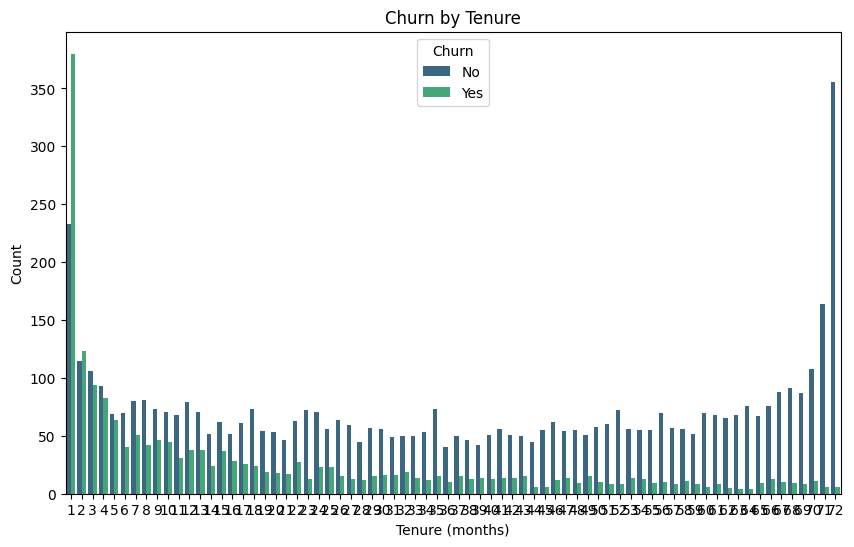

In [18]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x="tenure", hue="Churn", palette="viridis")
plt.title("Churn by Tenure")
plt.xlabel("Tenure (months)")
plt.ylabel("Count")
plt.legend(title="Churn")
plt.show()

In [19]:
print(df.groupby("tenure")["Churn"].value_counts(normalize=True).unstack())

Churn         No       Yes
tenure                    
1       0.380098  0.619902
2       0.483193  0.516807
3       0.530000  0.470000
4       0.528409  0.471591
5       0.518797  0.481203
...          ...       ...
68      0.910000  0.090000
69      0.915789  0.084211
70      0.907563  0.092437
71      0.964706  0.035294
72      0.983425  0.016575

[72 rows x 2 columns]


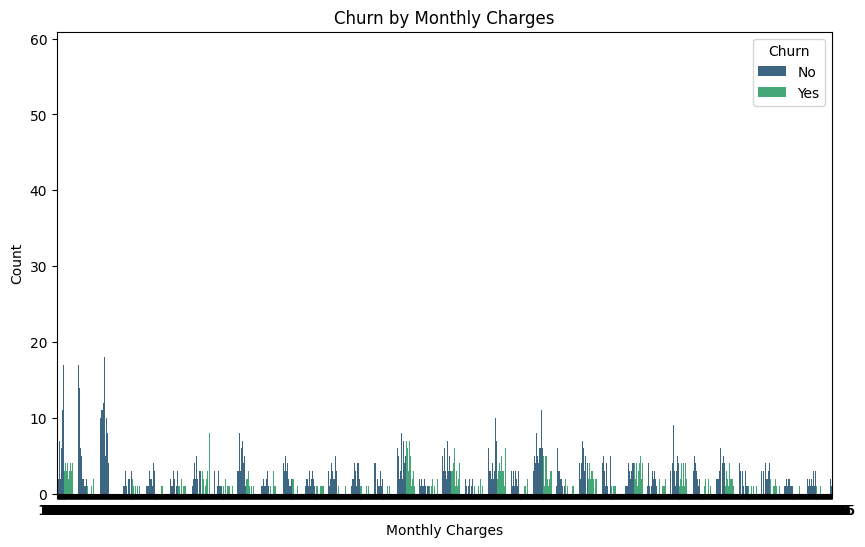

In [20]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x="MonthlyCharges", hue="Churn", palette="viridis")
plt.title("Churn by Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Count")
plt.legend(title="Churn")
plt.show()

In [21]:
df["Above_Median_Charges"] = df["MonthlyCharges"] > df["MonthlyCharges"].median()
print(df.groupby("Above_Median_Charges")["Churn"].value_counts(normalize=True).unstack())

Churn                       No       Yes
Above_Median_Charges                    
False                 0.820404  0.179596
True                  0.647879  0.352121


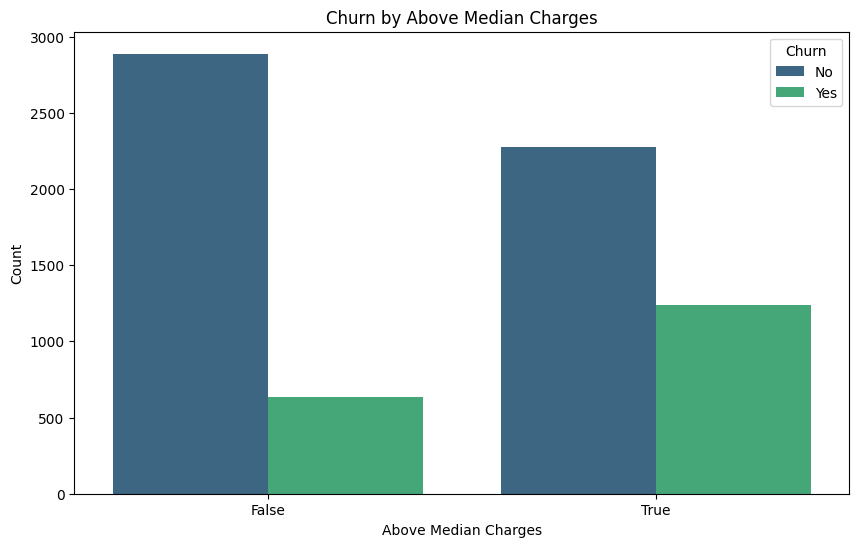

In [22]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x="Above_Median_Charges", hue="Churn", palette="viridis")
plt.title("Churn by Above Median Charges")
plt.xlabel("Above Median Charges")
plt.ylabel("Count")
plt.legend(title="Churn")

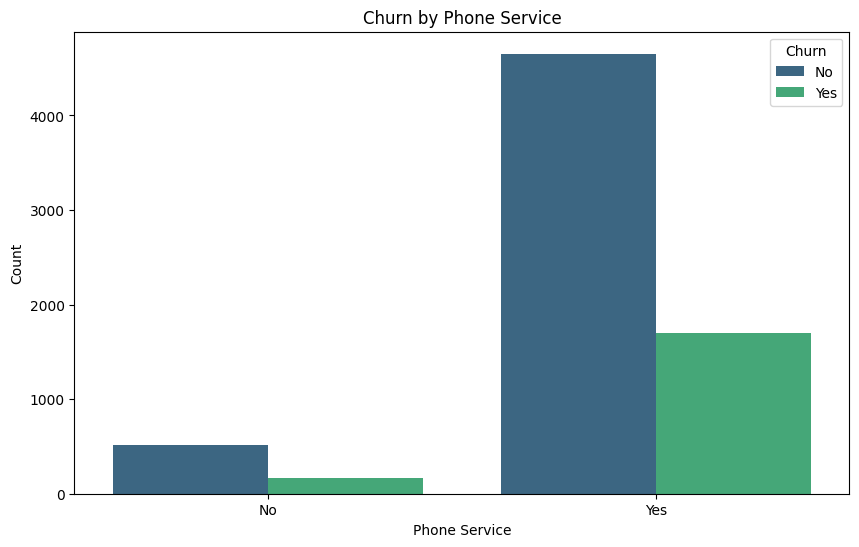

In [23]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x="PhoneService", hue="Churn", palette="viridis")
plt.title("Churn by Phone Service")
plt.xlabel("Phone Service")
plt.ylabel("Count")
plt.legend(title="Churn")

In [24]:
print(df.groupby('PhoneService')['Churn'].value_counts(normalize=True).unstack())

Churn               No       Yes
PhoneService                    
No            0.750000  0.250000
Yes           0.732525  0.267475


In [25]:
print(df.columns)

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn', 'Above_Median_Charges'],
      dtype='str')


In [ ]:
colonnes_to_drop = df.columns[df.nunique() > 5].tolist() + ["Churn"]
print(colonnes_to_drop)
for col in colonnes_to_drop:
    df[""]

['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [30]:

colonnes_to_check = df.select_dtypes(include=['object', 'bool']).columns.drop(colonnes_to_drop, errors='ignore')
print(colonnes_to_check)

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Above_Median_Charges'],
      dtype='str')


C:\Users\robin\AppData\Local\Temp\ipykernel_8228\589974068.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  colonnes_to_check = df.select_dtypes(include=['object', 'bool']).columns.drop(colonnes_to_drop, errors='ignore')


In [31]:
for col in colonnes_to_check:
    print(df.groupby(col)['Churn'].value_counts(normalize=True).unstack())

Churn         No       Yes
gender                    
Female  0.730405  0.269595
Male    0.737954  0.262046
Churn          No       Yes
Partner                    
No       0.670239  0.329761
Yes      0.802829  0.197171
Churn             No       Yes
Dependents                    
No          0.687209  0.312791
Yes         0.844688  0.155312
Churn               No       Yes
PhoneService                    
No            0.750000  0.250000
Yes           0.732525  0.267475
Churn                   No       Yes
MultipleLines                       
No                0.749188  0.250812
No phone service  0.750000  0.250000
Yes               0.713515  0.286485
Churn                  No       Yes
InternetService                    
DSL              0.810017  0.189983
Fiber optic      0.581072  0.418928
No               0.925658  0.074342
Churn                      No       Yes
OnlineSecurity                         
No                   0.582213  0.417787
No internet service  0.925658  0.074342

In [29]:
print(df.columns)

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn', 'Above_Median_Charges'],
      dtype='str')


So now 